# FR5 多模型仿真闭环验证分析

这个 notebook 读取 `fr5_evaluate_all_policies.py` 生成的批量仿真 rollout 结果。

这里的“验证准确率”定义为：在随机初始化仿真任务中，策略闭环执行后 `task_success=True` 的比例，即 task success rate。

当前分析固定默认 `assist` 条件开启，重点比较 `phase_guard=off` 与 `phase_guard=soft`。`off` 表示纯策略闭环推理；`soft` 表示在策略输出基础上加入软阶段约束，用于观察任务先验对闭环稳定性的影响。


## 0. 先运行批量验证

在终端运行，例如：

```bash
cd ~/gs_playground
uv run python demo/fr5_demo/fr5_evaluate_all_policies.py \
  --policy-pattern 'fr5_bc_*_tape_bc_v1.pt' \
  --conditions assist \
  --num-seeds 10 \
  --max-steps 250 \
  --hz 10 \
  --lookahead-frames 3 \
  --max-action-deg 45 \
  --max-gripper-delta 0.05 \
  --sim-rgb-source visual \
  --phase-guards soft off \
  --policy-ablations normal \
  --action-ema 0.25 \
  --max-action-step-deg 12 \
  --run-name thesis_eval_ablation_v1
```

输出目录：

```text
demo/fr5_demo/data/policy_rollouts/batch_eval/thesis_eval_ablation_v1/
```


In [18]:
from pathlib import Path
from datetime import datetime
import json
import math

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'demo/fr5_demo').exists():
    ROOT = Path('../../..').resolve()

BATCH_ROOT = ROOT / 'demo/fr5_demo/data/policy_rollouts/batch_eval'
POLICY_DIR = ROOT / 'demo/fr5_demo/data/il_policies'
FIG_ROOT = ROOT / 'demo/fr5_demo/data/il_policies/figures'
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
FIG_DIR = FIG_ROOT / f'policy_batch_eval_{RUN_ID}'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 留空表示自动选择最新 policy_eval_summary.json；也可以固定为某个 run 名。
SELECTED_RUN_NAME = 'thesis_eval_ablation_v1'
DEFAULT_CONDITION = 'assist'
PREFERRED_PHASE_GUARDS = ['off', 'soft']
PREFERRED_POLICY_ABLATION = 'normal'

def latest_summary():
    if SELECTED_RUN_NAME:
        selected = BATCH_ROOT / SELECTED_RUN_NAME / 'policy_eval_summary.json'
        if selected.exists():
            return selected
        raise RuntimeError(f'指定的 policy_eval_summary.json 不存在: {selected}')
    candidates = sorted(BATCH_ROOT.glob('*/policy_eval_summary.json'), key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise RuntimeError('没有找到 policy_eval_summary.json。请先运行 fr5_evaluate_all_policies.py。')
    return candidates[-1]

SUMMARY_PATH = latest_summary()
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
rows = summary.get('rows', [])
aggs = summary.get('aggregates', [])
print('summary:', SUMMARY_PATH)
print('rows:', len(rows), 'aggregates:', len(aggs))
print('condition used:', DEFAULT_CONDITION)
print('fig dir:', FIG_DIR)


summary: /home/sanchez/gs_playground/demo/fr5_demo/data/policy_rollouts/batch_eval/thesis_eval_ablation_v1/policy_eval_summary.json
rows: 60 aggregates: 6
condition used: assist
fig dir: /home/sanchez/gs_playground/demo/fr5_demo/data/il_policies/figures/policy_batch_eval_20260525_191933


In [19]:
def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches='tight')
    print('saved:', path)

def phase_of(row):
    return str(row.get('phase_guard', 'off') or 'off')

def ablation_of(row):
    return str(row.get('policy_ablation', 'normal') or 'normal')

def row_matches(row, *, condition=DEFAULT_CONDITION, ablation=PREFERRED_POLICY_ABLATION):
    return str(row.get('condition', '')) == condition and ablation_of(row) == ablation

def sorted_models(aggs):
    return sorted({a['policy_name'] for a in aggs if row_matches(a)})

def available_phase_guards(aggs):
    present = {phase_of(a) for a in aggs if row_matches(a)}
    ordered = [p for p in PREFERRED_PHASE_GUARDS if p in present]
    ordered += sorted(present - set(ordered))
    return ordered

def get_agg(model, phase_guard, *, condition=DEFAULT_CONDITION, ablation=PREFERRED_POLICY_ABLATION):
    for a in aggs:
        if (
            a.get('policy_name') == model
            and str(a.get('condition', '')) == condition
            and phase_of(a) == phase_guard
            and ablation_of(a) == ablation
        ):
            return a
    return None

models = sorted_models(aggs)
phase_guards = available_phase_guards(aggs)
print('models:', models)
print('phase_guards:', phase_guards)
print('condition:', DEFAULT_CONDITION, 'policy_ablation:', PREFERRED_POLICY_ABLATION)
for a in aggs:
    if not row_matches(a):
        continue
    print(
        f"{a['policy_name']:35s} phase={phase_of(a):6s} "
        f"success={a['success_rate']:.3f} "
        f"place_err={a['place_error_mean_m']:.4f}m episodes={a['episodes']}"
    )


models: ['fr5_bc_cnn_small_tape_bc_v1', 'fr5_bc_spatial_softmax_tape_bc_v1', 'fr5_bc_state_mlp_tape_bc_v1']
phase_guards: ['off', 'soft']
condition: assist policy_ablation: normal
fr5_bc_cnn_small_tape_bc_v1         phase=off    success=0.000 place_err=0.3959m episodes=10
fr5_bc_cnn_small_tape_bc_v1         phase=soft   success=1.000 place_err=0.0116m episodes=10
fr5_bc_spatial_softmax_tape_bc_v1   phase=off    success=0.000 place_err=0.3552m episodes=10
fr5_bc_spatial_softmax_tape_bc_v1   phase=soft   success=1.000 place_err=0.0106m episodes=10
fr5_bc_state_mlp_tape_bc_v1         phase=off    success=0.000 place_err=0.4196m episodes=10
fr5_bc_state_mlp_tape_bc_v1         phase=soft   success=1.000 place_err=0.0078m episodes=10


## 1. off 与 soft 的闭环验证准确率

这里的准确率是随机仿真环境中的任务成功率：`success_rate = task_success 数 / rollout 总数`。

- `off`：纯策略闭环推理，不启用阶段约束。
- `soft`：策略输出仍然生效，但加入软阶段约束修正，用于测试任务先验是否能改善长时序稳定性。


saved: /home/sanchez/gs_playground/demo/fr5_demo/data/il_policies/figures/policy_batch_eval_20260525_191933/01_success_rate_by_phase_guard.png


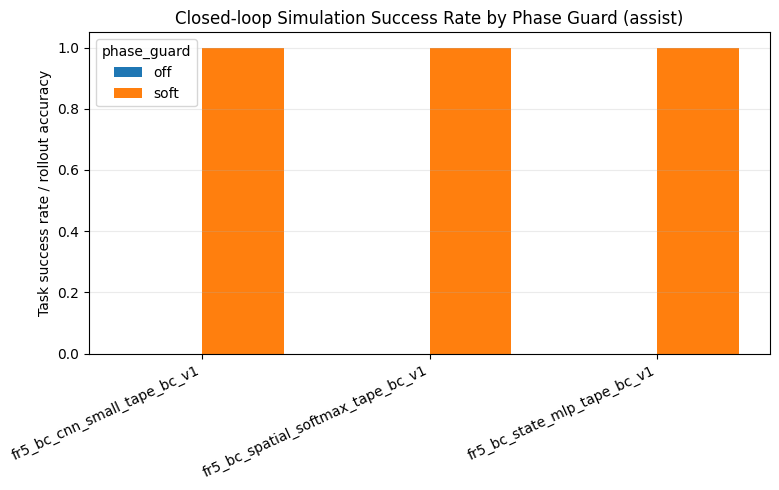

In [20]:
x = np.arange(len(models))
width = 0.36 if len(phase_guards) > 1 else 0.55
plt.figure(figsize=(max(8, len(models)*1.6), 5))
for i, phase in enumerate(phase_guards):
    vals = [(get_agg(m, phase) or {}).get('success_rate', np.nan) for m in models]
    offset = (i - (len(phase_guards)-1)/2) * width
    plt.bar(x + offset, vals, width=width, label=phase)
plt.xticks(x, models, rotation=25, ha='right')
plt.ylim(0, 1.05)
plt.ylabel('Task success rate / rollout accuracy')
plt.title(f'Closed-loop Simulation Success Rate by Phase Guard ({DEFAULT_CONDITION})')
plt.grid(axis='y', alpha=0.25)
plt.legend(title='phase_guard')
savefig('01_success_rate_by_phase_guard.png')
plt.show()


## 2. 终点放置误差

成功率之外，放置误差能显示失败程度。虚线是任务判定半径。

saved: /home/sanchez/gs_playground/demo/fr5_demo/data/il_policies/figures/policy_batch_eval_20260525_191933/02_place_error_by_phase_guard.png


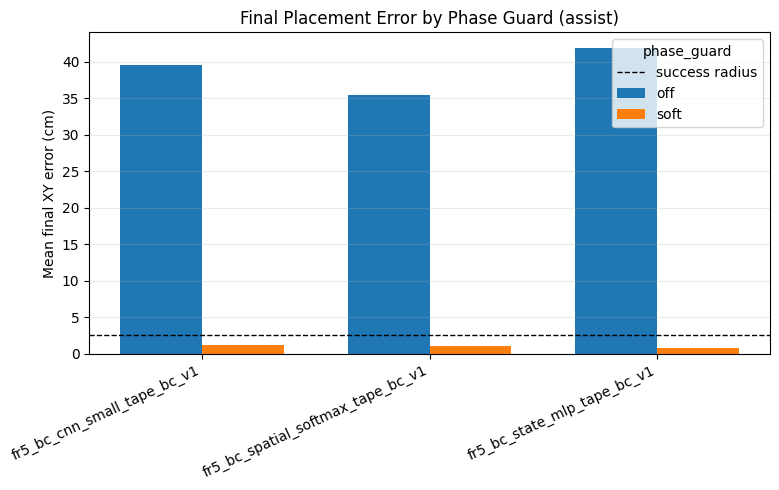

In [21]:
plt.figure(figsize=(max(8, len(models)*1.6), 5))
for i, phase in enumerate(phase_guards):
    vals = [(get_agg(m, phase) or {}).get('place_error_mean_m', np.nan) for m in models]
    offset = (i - (len(phase_guards)-1)/2) * width
    plt.bar(x + offset, np.asarray(vals) * 100.0, width=width, label=phase)
radii = [r.get('place_success_radius_m', np.nan) for r in rows if 'place_success_radius_m' in r]
if radii:
    plt.axhline(float(np.nanmedian(radii))*100.0, color='k', linestyle='--', linewidth=1, label='success radius')
plt.xticks(x, models, rotation=25, ha='right')
plt.ylabel('Mean final XY error (cm)')
plt.title(f'Final Placement Error by Phase Guard ({DEFAULT_CONDITION})')
plt.grid(axis='y', alpha=0.25)
plt.legend(title='phase_guard')
savefig('02_place_error_by_phase_guard.png')
plt.show()


## 3. off 与 soft 差距

本节不再比较 `assist/noassist`，因为当前验证默认固定 `assist` 开启。这里比较的是同一模型在 `phase_guard=off` 与 `phase_guard=soft` 下的闭环表现差异。

`soft - off` 越大，说明软阶段约束对长时序任务稳定性帮助越明显；如果 `off` 和 `soft` 都差，优先怀疑模型泛化、观测输入或训练数据覆盖不足。


saved: /home/sanchez/gs_playground/demo/fr5_demo/data/il_policies/figures/policy_batch_eval_20260525_191933/03_soft_off_success_gap.png


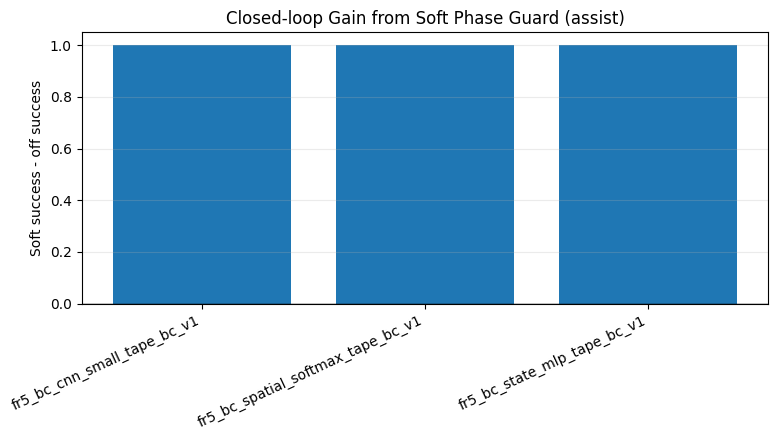

In [22]:
if {'off', 'soft'}.issubset(set(phase_guards)):
    off_vals = np.asarray([(get_agg(m, 'off') or {}).get('success_rate', np.nan) for m in models])
    soft_vals = np.asarray([(get_agg(m, 'soft') or {}).get('success_rate', np.nan) for m in models])
    plt.figure(figsize=(max(8, len(models)*1.5), 4.5))
    plt.bar(x, soft_vals - off_vals)
    plt.axhline(0, color='k', linewidth=1)
    plt.xticks(x, models, rotation=25, ha='right')
    plt.ylabel('Soft success - off success')
    plt.title(f'Closed-loop Gain from Soft Phase Guard ({DEFAULT_CONDITION})')
    plt.grid(axis='y', alpha=0.25)
    savefig('03_soft_off_success_gap.png')
    plt.show()
else:
    print('需要同时运行 phase_guard=off 和 phase_guard=soft 才能画 gap。')


## 4. 控制稳定性诊断

动作限幅比例高，说明模型输出或限幅设置不合理；TCP 最低高度过低，说明可能有仿真下坠、穿模或危险动作。这里按 `off/soft` 分别显示。


saved: /home/sanchez/gs_playground/demo/fr5_demo/data/il_policies/figures/policy_batch_eval_20260525_191933/04_control_stability_metrics_by_phase_guard.png


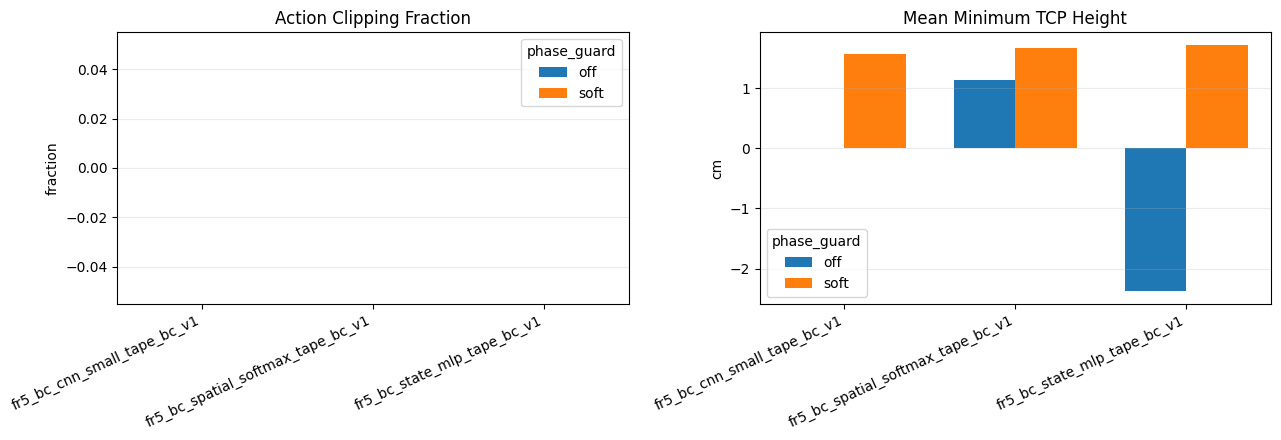

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, phase in enumerate(phase_guards):
    off = (i - (len(phase_guards)-1)/2) * width
    clip_vals = [(get_agg(m, phase) or {}).get('clip_fraction_mean', np.nan) for m in models]
    z_vals = [(get_agg(m, phase) or {}).get('min_tcp_z_mean_m', np.nan) for m in models]
    axes[0].bar(x + off, clip_vals, width=width, label=phase)
    axes[1].bar(x + off, np.asarray(z_vals)*100.0, width=width, label=phase)
axes[0].set_title('Action Clipping Fraction')
axes[0].set_ylabel('fraction')
axes[1].set_title('Mean Minimum TCP Height')
axes[1].set_ylabel('cm')
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha='right')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(title='phase_guard')
savefig('04_control_stability_metrics_by_phase_guard.png')
plt.show()


## 5. 逐 seed 分布

这张图用于说明随机初始位置下的稳定性，而不是只展示平均值。

/tmp/ipykernel_201761/1272314395.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


saved: /home/sanchez/gs_playground/demo/fr5_demo/data/il_policies/figures/policy_batch_eval_20260525_191933/05_per_seed_error_distribution_by_phase_guard.png


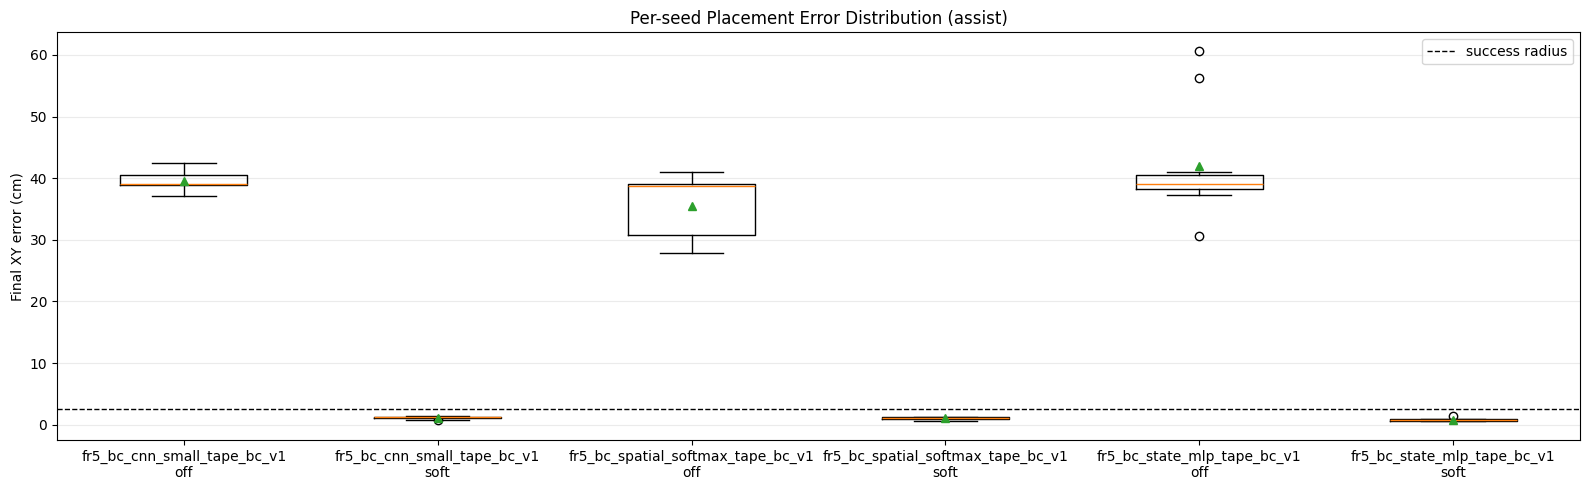

In [ ]:
labels = []
data = []
for m in models:
    for phase in phase_guards:
        vals = [
            r['place_error_xy_m'] * 100.0
            for r in rows
            if r.get('policy_name') == m
            and str(r.get('condition', '')) == DEFAULT_CONDITION
            and phase_of(r) == phase
            and ablation_of(r) == PREFERRED_POLICY_ABLATION
        ]
        if vals:
            labels.append(f'{m}\n{phase}')
            data.append(vals)
plt.figure(figsize=(max(16, len(labels)*0.9), 5))
plt.boxplot(data, labels=labels, showmeans=True)
radii = [r.get('place_success_radius_m', np.nan) for r in rows if 'place_success_radius_m' in r]
if radii:
    plt.axhline(float(np.nanmedian(radii))*100.0, color='k', linestyle='--', linewidth=1, label='success radius')
plt.ylabel('Final XY error (cm)')
plt.title(f'Per-seed Placement Error Distribution ({DEFAULT_CONDITION})')
plt.grid(axis='y', alpha=0.25)
plt.legend()
savefig('05_per_seed_error_distribution_by_phase_guard.png')
plt.show()


## 6. off-only 三模型距离诊断

这张图只看 `phase_guard=off`，但不比较成功率。因为当前 off 全部失败，成功率无法区分模型；这里改用距离与位移指标观察潜在差异：是否接近过胶带、是否移动了胶带、最终离目标还有多远。

saved: /home/sanchez/gs_playground/demo/fr5_demo/data/il_policies/figures/policy_batch_eval_20260525_191933/06_off_only_distance_diagnostics.png


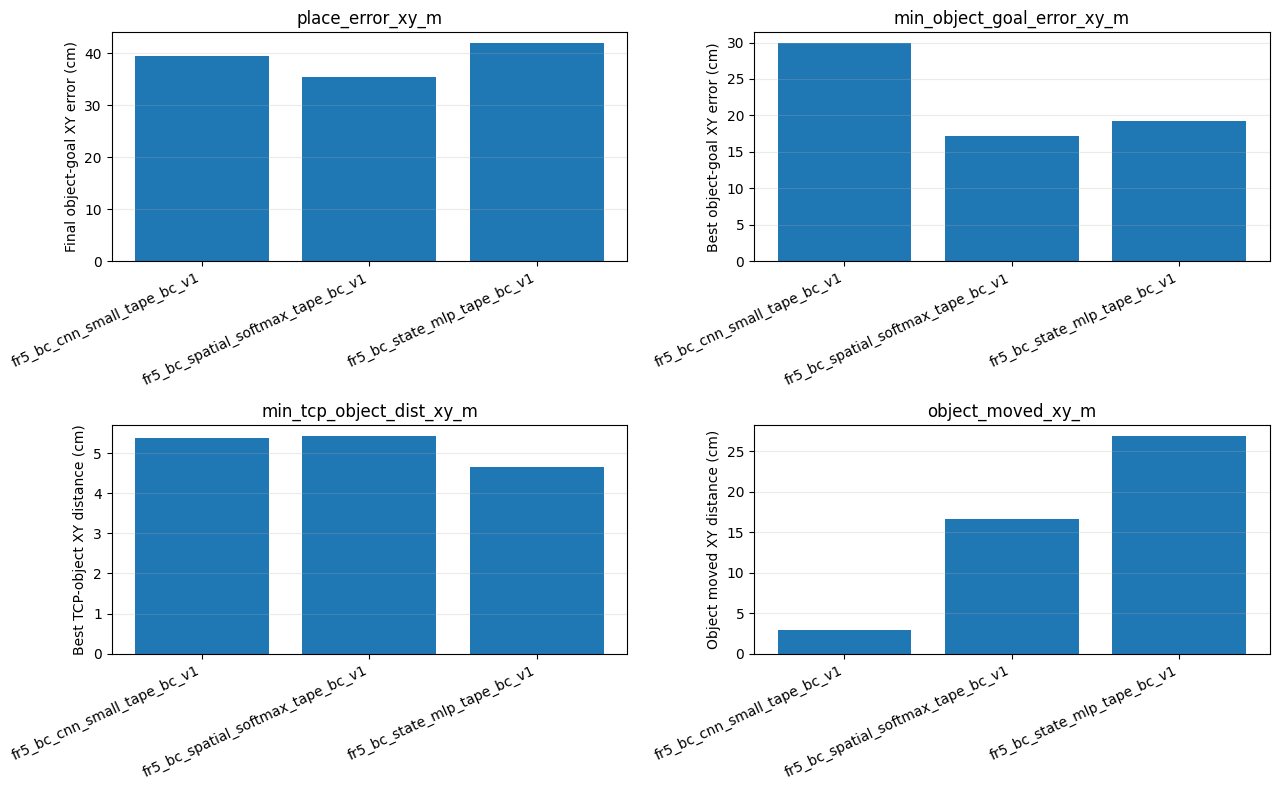

In [25]:
def mean_row_metric(model, phase, key, scale=1.0):
    vals = [
        float(r.get(key, np.nan)) * scale
        for r in rows
        if r.get('policy_name') == model
        and str(r.get('condition', '')) == DEFAULT_CONDITION
        and phase_of(r) == phase
        and ablation_of(r) == PREFERRED_POLICY_ABLATION
    ]
    vals = np.asarray(vals, dtype=np.float64)
    return float(np.nanmean(vals)) if vals.size else np.nan

off_phase = 'off'
distance_metrics = [
    ('place_error_xy_m', 'Final object-goal XY error (cm)', 100.0),
    ('min_object_goal_error_xy_m', 'Best object-goal XY error (cm)', 100.0),
    ('min_tcp_object_dist_xy_m', 'Best TCP-object XY distance (cm)', 100.0),
    ('object_moved_xy_m', 'Object moved XY distance (cm)', 100.0),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()
for ax, (key, ylabel, scale) in zip(axes, distance_metrics):
    vals = [mean_row_metric(m, off_phase, key, scale) for m in models]
    ax.bar(x, vals)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(key)
    ax.grid(axis='y', alpha=0.25)
savefig('06_off_only_distance_diagnostics.png')
plt.show()


## 7. 训练指标与闭环成功率关系

训练/验证 loss 只能说明监督回归误差，不能替代闭环任务成功率。这张图用于论文中说明 offline regression metric 与 rollout metric 的区别。

{'history': 'fr5_bc_state_mlp_tape_bc_v1.history.json', 'policy_name_guess': 'fr5_bc_state_mlp_tape_bc_v1', 'best_epoch': 31, 'best_val_loss': 0.0004108317226309319, 'arm_mae_deg': 0.36030982878709156, 'arm_mae_source': 'val_arm_mae_deg', 'val_arm_mae_deg': 0.36030982878709156, 'test_arm_mae_deg': nan}
{'history': 'fr5_bc_spatial_softmax_tape_bc_v1.history.json', 'policy_name_guess': 'fr5_bc_spatial_softmax_tape_bc_v1', 'best_epoch': 34, 'best_val_loss': 0.00011029906771367292, 'arm_mae_deg': 0.2562138566954168, 'arm_mae_source': 'val_arm_mae_deg', 'val_arm_mae_deg': 0.2562138566954168, 'test_arm_mae_deg': nan}
{'history': 'fr5_bc_cnn_small_tape_bc_v1.history.json', 'policy_name_guess': 'fr5_bc_cnn_small_tape_bc_v1', 'best_epoch': 50, 'best_val_loss': 0.000338279790908326, 'arm_mae_deg': 0.4121602764992878, 'arm_mae_source': 'val_arm_mae_deg', 'val_arm_mae_deg': 0.4121602764992878, 'test_arm_mae_deg': nan}
saved: /home/sanchez/gs_playground/demo/fr5_demo/data/il_policies/figures/policy

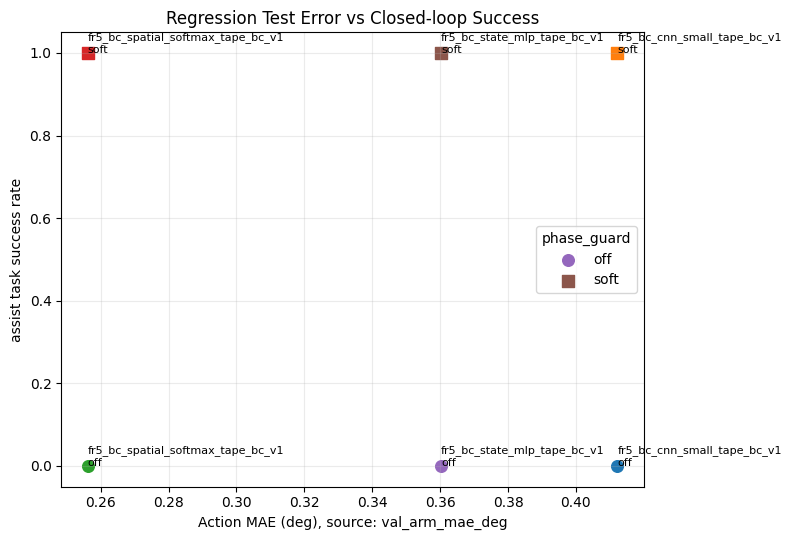

In [26]:
hist_rows = []
for hp in POLICY_DIR.glob('*.history.json'):
    try:
        hist = json.loads(hp.read_text(encoding='utf-8'))
        if not hist:
            continue
        best = min(hist, key=lambda r: float(r.get('val_loss', float('inf'))))
        metric_value = best.get('test_arm_mae_deg', best.get('val_arm_mae_deg', np.nan))
        metric_name = 'test_arm_mae_deg' if 'test_arm_mae_deg' in best else 'val_arm_mae_deg'
        hist_rows.append({
            'history': hp.name,
            'policy_name_guess': hp.stem.replace('.history', ''),
            'best_epoch': best.get('epoch'),
            'best_val_loss': float(best.get('val_loss', np.nan)),
            'arm_mae_deg': float(metric_value),
            'arm_mae_source': metric_name,
            'val_arm_mae_deg': float(best.get('val_arm_mae_deg', np.nan)),
            'test_arm_mae_deg': float(best.get('test_arm_mae_deg', np.nan)),
        })
    except Exception as exc:
        print('skip history', hp, exc)

for row in hist_rows:
    print(row)

plt.figure(figsize=(8, 5.5))
plotted = 0
for a in aggs:
    if not row_matches(a):
        continue
    candidates = [
        h for h in hist_rows
        if h['policy_name_guess'].replace('_tape_bc_v1','') in a['policy_name']
        or a['policy_name'] in h['policy_name_guess']
    ]
    if not candidates:
        continue
    h = candidates[0]
    x_val = h['arm_mae_deg']
    if not np.isfinite(x_val):
        continue
    marker = 'o' if phase_of(a) == 'off' else 's'
    plt.scatter(x_val, a['success_rate'], s=70, marker=marker, label=phase_of(a))
    plt.text(x_val, a['success_rate'], f"{a['policy_name']}\n{phase_of(a)}", fontsize=8)
    plotted += 1
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(), title='phase_guard')
metric_sources = sorted({h['arm_mae_source'] for h in hist_rows if np.isfinite(h['arm_mae_deg'])})
source_label = ', '.join(metric_sources) if metric_sources else 'missing arm MAE'
plt.xlabel(f'Action MAE (deg), source: {source_label}')
plt.ylabel(f'{DEFAULT_CONDITION} task success rate')
plt.title('Regression Test Error vs Closed-loop Success')
plt.grid(True, alpha=0.25)
if plotted == 0:
    print('没有可画点：history 里缺少 test_arm_mae_deg/val_arm_mae_deg，或模型名没有匹配。')
savefig('07_mae_vs_rollout_success_by_phase_guard.png')
plt.show()


## 8. 建议提供的图片

建议至少保留这些图：

1. `01_success_rate_by_phase_guard.png`：不同模型在 `off/soft` 下的闭环任务成功率，这是主结果图。
2. `02_place_error_by_phase_guard.png`：终点放置误差，说明失败程度。
3. `03_soft_off_success_gap.png`：`soft` 相比 `off` 的提升幅度，说明阶段先验对闭环稳定性的影响。
4. `04_control_stability_metrics_by_phase_guard.png`：动作限幅和 TCP 高度，说明安全性和控制稳定性。
5. `05_per_seed_error_distribution_by_phase_guard.png`：随机初始位置下的误差分布，说明泛化稳定性。
6. `06_off_only_distance_diagnostics.png`：只看 `phase_guard=off` 的距离/位移诊断；当 off 成功率全为 0 时，用它讨论模型之间的潜在差异。
7. `07_mae_vs_rollout_success_by_phase_guard.png`：监督验证/测试误差与闭环成功率关系，说明为什么不能只看 BC loss。

如果篇幅有限，主文放 1、2、3；其余放实验分析或附录。
